In [1]:
"""
Well Turbidity Analysis using Hough Circle Detection

This script:
1. Detects circular wells in 3x4 plate images.
2. Crops inner regions of each well.
3. Computes turbidity-related metrics:
      - Contrast (std deviation)
      - Laplacian variance (sharpness / blur)
      - Mean intensity
4. Aggregates results row-wise.
5. Outputs a Time x Row x Metric array.

Designed for bacterial growth / turbidity monitoring.
"""

!pip install opencv-python numpy matplotlib

In [2]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
import matplotlib.dates as mdates

In [3]:
# ==========================================================
# 1. WELL DETECTION
# ==========================================================

def detect_wells(image_path,
                 shrink_factor,
                 visualize,
                 debug,
                 expected_wells,
                 blur_kernel,
                 blur_sigma,
                 hough_dp,
                 hough_minDist,
                 hough_param1,
                 hough_param2,
                 hough_minRadius,
                 hough_maxRadius,
                 fallback_minDist,
                 fallback_param2,
                 fallback_minRadius,
                 fallback_maxRadius):
    """
    Detect circular wells using Hough Circle Transform.

    Workflow:
    1. Convert image to grayscale.
    2. Apply Gaussian blur to stabilize circle detection.
    3. Run HoughCircles with primary parameters.
    4. If number of detected wells != expected_wells,
       run fallback detection with stricter parameters.

    Parameters
    ----------
    shrink_factor : float
        Fraction of detected radius used for measurement.
        Smaller values exclude well wall reflections.

    debug : bool
        Shows intermediate preprocessing steps.

    visualize : bool
        Overlays detected circles on image.

    expected_wells : int
        Number of wells expected (e.g., 12 for 3x4 plate).

    Hough Parameters:
    ------------------
    hough_dp :
        Inverse resolution ratio for accumulator.
        Usually 1.2 works well.

    hough_minDist :
        Minimum allowed distance between circle centers.
        Increase if duplicate circles appear.

    hough_param1 :
        Higher Canny threshold (internal edge detection).

    hough_param2 :
        Accumulator threshold.
        Lower → more circles detected.
        Higher → stricter detection.

    hough_minRadius / hough_maxRadius :
        Allowed radius range.
        Tightening this reduces false detections.

    Fallback parameters:
        Used if first detection does not match expected_wells.
        Typically stricter to reduce false positives.
    """

    img = cv2.imread(image_path)

    # Debug: show original
    if debug:
        plt.figure(figsize=(6,5))
        plt.title("Original")
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.axis("off")
        plt.show()

    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    if debug:
        plt.figure(figsize=(6,5))
        plt.title("Grayscale")
        plt.imshow(gray, cmap="gray")
        plt.axis("off")
        plt.show()

    # Gaussian smoothing improves stability of Hough detection
    blur = cv2.GaussianBlur(gray, blur_kernel, blur_sigma)

    if debug:
        plt.figure(figsize=(6,5))
        plt.title("Gaussian Blur")
        plt.imshow(blur, cmap="gray")
        plt.axis("off")
        plt.show()

    # -------- Primary Detection --------
    circles = cv2.HoughCircles(
        blur,
        cv2.HOUGH_GRADIENT,
        dp=hough_dp,
        minDist=hough_minDist,
        param1=hough_param1,
        param2=hough_param2,
        minRadius=hough_minRadius,
        maxRadius=hough_maxRadius
    )

    detected = len(circles[0]) if circles is not None else 0
    print(f"Initial circles detected: {detected}")

    # -------- Fallback Detection --------
    if detected != expected_wells:
        circles = cv2.HoughCircles(
            blur,
            cv2.HOUGH_GRADIENT,
            dp=hough_dp,
            minDist=fallback_minDist,
            param1=hough_param1,
            param2=fallback_param2,
            minRadius=fallback_minRadius,
            maxRadius=fallback_maxRadius
        )

    vis = img.copy()

    if circles is None:
        print("No circles detected")
        circles = []
    else:
        circles = np.round(circles[0]).astype(int)
        circles = sorted(circles, key=lambda c: (c[1], c[0]))

        if visualize:
            for (x, y, r) in circles:
                r_inner = int(r * shrink_factor)

                # Green = detected outer boundary
                cv2.circle(vis, (x, y), r, (0,255,0), 2)

                # Blue = region used for metric computation
                cv2.circle(vis, (x, y), r_inner, (255,0,0), 2)

                # Red = center
                cv2.circle(vis, (x, y), 3, (0,0,255), -1)

            print(f"Final detected circles: {len(circles)}")

            plt.figure(figsize=(8,6))
            plt.title("Final Detection")
            plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
            plt.axis("off")
            plt.show()

    return img, circles

In [4]:
# ==========================================================
# 2. WELL CROPPING
# ==========================================================

def crop_wells(img, circles, shrink_factor):
    """
    Crop inner square region of each detected well.

    shrink_factor controls how much of the detected radius
    is used for measurement.

    Smaller → avoids well wall reflections.
    Larger → includes more of liquid region.
    """
    wells = []

    for (x, y, r) in circles:
        r_inner = int(r * shrink_factor)
        crop = img[y-r_inner:y+r_inner, x-r_inner:x+r_inner]
        wells.append(crop)

    return wells

In [5]:
# ==========================================================
# 3. METRIC COMPUTATION
# ==========================================================

def well_metrics(well):
    """
    Compute turbidity-related metrics:

    contrast:
        Standard deviation of intensity.
        Lower as turbidity increases.

    laplacian_var:
        Sharpness measure (blur).
        Lower = more blur = more turbidity.

    mean_int:
        Average brightness.
    """

    gray = cv2.cvtColor(well, cv2.COLOR_BGR2GRAY)

    h, w = gray.shape
    center = (w//2, h//2)
    radius = min(center)

    mask = np.zeros_like(gray)
    cv2.circle(mask, center, radius, 255, -1)

    pixels = gray[mask == 255]

    contrast = np.std(pixels)
    laplacian_var = cv2.Laplacian(pixels, cv2.CV_64F).var()
    mean_int = np.mean(pixels)

    return contrast, laplacian_var, mean_int



In [6]:
# ==========================================================
# 4. ROW AVERAGING
# ==========================================================

def row_averages(metrics, expected_wells, num_rows):
    """
    Compute row-wise averages.

    Parameters
    ----------
    metrics : ndarray
        Array of shape (expected_wells, num_metrics)

    expected_wells : int
        Total number of detected wells.

    num_rows : int
        Number of well rows in the plate layout.

    Notes
    -----
    Assumes wells are ordered row-major
    (left-to-right, top-to-bottom).
    """

    wells_per_row = expected_wells // num_rows

    row_data = []
    for i in range(0, expected_wells, wells_per_row):
        row = metrics[i:i+wells_per_row]
        row_data.append(np.mean(row, axis=0))

    return np.array(row_data)


In [7]:
# ==========================================================
# 5. Building the Final DataFrame
# ==========================================================

def build_dataframe(image_list, all_time_data, gravity_value, row_labels):
    
    timestamps = []
    
    for image_path in image_list:
        filename = os.path.basename(image_path)
        name_without_ext = os.path.splitext(filename)[0]
        dt = datetime.strptime(name_without_ext, "%Y%m%d %H%M%S")
        timestamps.append(dt)

    records = []

    for t_idx, timestamp in enumerate(timestamps):
        for row_idx in range(len(row_labels)):
            records.append({
                "Time": timestamp,
                "Sample": row_labels[row_idx],
                "Gravity": gravity_value,
                "Contrast": all_time_data[t_idx, row_idx, 0],
                "Sharpness": all_time_data[t_idx, row_idx, 1],
                "Mean_Intensity": all_time_data[t_idx, row_idx, 2],
            })

    return pd.DataFrame(records)

In [ ]:
# -------------------------------
# 6. Extract timestamps
# -------------------------------

def extract_timestamps(image_list):
    timestamps = []
    for image_path in image_list:
        filename = os.path.basename(image_path)
        name_without_ext = os.path.splitext(filename)[0]
        dt = datetime.strptime(name_without_ext, "%Y%m%d %H%M%S")
        timestamps.append(dt)
    return np.array(timestamps)

timestamps_earth = extract_timestamps(image_list_earth)
timestamps_mars = extract_timestamps(image_list_mars)

metric_names = ["Contrast", "Sharpness", "Mean Intensity"]
row_labels = ["Blank", "Microbe 1", "Microbe 2"]

In [8]:
# =========================
# USER CONFIGURATION
# =========================

FOLDER_PATH = "Earth"

EXPECTED_WELLS = 12      # Change if plate layout changes
NUM_ROWS = 3             # Number of rows in the plate (e.g., 3 for 3x4 layout)

# --- Crop ---
SHRINK_FACTOR = 0.3      # Smaller excludes wall reflections

# --- Debug / Visualization ---
DEBUG = False            # Show intermediate steps for troubleshooting
VISUALIZE = False         # Show detected circles on images

# --- Blur ---
BLUR_KERNEL = (9,9)      # Larger → smoother → fewer false edges
BLUR_SIGMA = 2           # Controls smoothing strength

# --- Primary Hough ---
HOUGH_DP = 1.2
HOUGH_MIN_DIST = 150     # Increase if duplicate detections
HOUGH_PARAM1 = 100
HOUGH_PARAM2 = 30        # Lower → more circles detected
HOUGH_MIN_RADIUS = 80
HOUGH_MAX_RADIUS = 150

# --- Fallback Hough ---
FALLBACK_MIN_DIST = 300
FALLBACK_PARAM2 = 40     # Stricter threshold
FALLBACK_MIN_RADIUS = 150
FALLBACK_MAX_RADIUS = 200



# ==========================================================
# MAIN EXECUTION PIPELINE
# ==========================================================
"""
Main Processing Loop

For each image in FOLDER_PATH:

1. Detect circular wells using Hough transform.
2. Crop inner region of each well.
3. Compute turbidity-related metrics:
       - Contrast (intensity standard deviation)
       - Laplacian variance (sharpness / blur proxy)
       - Mean intensity
4. Average wells row-wise.
5. Store results as:

    all_time_data → shape (Time, Row, Metric)

Where:
    Time   = number of images processed
    Row    = number of well rows (e.g., 3)
    Metric = 3 values per row:
             [Contrast, Laplacian, Mean]

Final output shape:
    (Number_of_images, 3, 3)
"""

# Collect all image paths from the selected folder
image_list_earth = sorted([
    os.path.join(FOLDER_PATH, f)
    for f in os.listdir(FOLDER_PATH)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
])

# This will store data across time points
all_time_data_earth = []

for image_path in image_list_earth:
    print(f"\nProcessing: {image_path}")

    # ---------------------------
    # 1. Detect Wells
    # ---------------------------
    img, circles = detect_wells(
        image_path,
        SHRINK_FACTOR,
        VISUALIZE,
        DEBUG,
        EXPECTED_WELLS,
        BLUR_KERNEL,
        BLUR_SIGMA,
        HOUGH_DP,
        HOUGH_MIN_DIST,
        HOUGH_PARAM1,
        HOUGH_PARAM2,
        HOUGH_MIN_RADIUS,
        HOUGH_MAX_RADIUS,
        FALLBACK_MIN_DIST,
        FALLBACK_PARAM2,
        FALLBACK_MIN_RADIUS,
        FALLBACK_MAX_RADIUS
    )

    # ---------------------------
    # 2. Crop Wells
    # ---------------------------
    wells = crop_wells(img, circles, SHRINK_FACTOR)

    # ---------------------------
    # 3. Compute Metrics
    # ---------------------------
    metrics = np.array([well_metrics(w) for w in wells])

    # ---------------------------
    # 4. Row Averaging
    # ---------------------------
    row_data = row_averages(metrics, EXPECTED_WELLS, NUM_ROWS)

    # Store results for this time point
    all_time_data_earth.append(row_data)

# Convert list → numpy array
all_time_data_earth = np.array(all_time_data_earth)

# ---------------------------
# Final Output Summary
# ---------------------------
print("\n==============================")
print("Final Output Summary")
print("==============================")

print(f"Data dimensions (# of Images x Well Rows x Measurements): {all_time_data_earth.shape}")
print()

print(f"\nRow-wise averages (Contrast, Sharpness, Mean Intensity): \n{all_time_data_earth}\n")


Processing: Earth\20260129 151049.png
Initial circles detected: 12

Processing: Earth\20260129 173542.png
Initial circles detected: 12

Processing: Earth\20260129 190848.png
Initial circles detected: 12

Processing: Earth\20260130 121150.png
Initial circles detected: 12

Processing: Earth\20260130 163823.png
Initial circles detected: 12

Processing: Earth\20260130 192318.png
Initial circles detected: 12

Processing: Earth\20260131 142811.png
Initial circles detected: 12

Final Output Summary
Data dimensions (# of Images x Well Rows x Measurements): (7, 3, 3)


Row-wise averages (Contrast, Sharpness, Mean Intensity): 
[[[  9.98703151  32.11003936 154.59775766]
  [ 10.86001533  44.95607203 158.01795657]
  [ 10.55045556  42.58002265 157.15085128]]

 [[  8.59327494  19.56674258 137.81599402]
  [  8.92121     24.02288792 142.86066928]
  [  9.91625882  30.99406573 144.85868348]]

 [[  8.67864579  25.54046908 146.70147744]
  [  8.52199165  26.97390939 151.36499125]
  [  8.56923471  29.812207

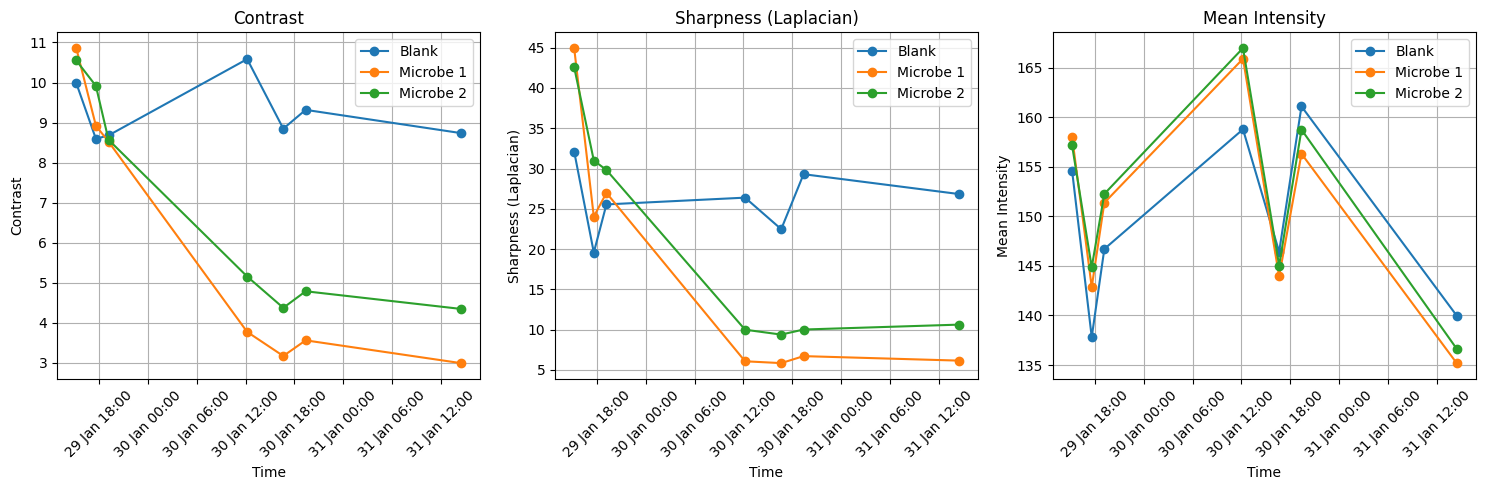

In [9]:
# Extract datetime from filenames
timestamps = []

for image_path in image_list_earth:
    filename = os.path.basename(image_path)
    name_without_ext = os.path.splitext(filename)[0]
    
    dt = datetime.strptime(name_without_ext, "%Y%m%d %H%M%S")
    timestamps.append(dt)

timestamps = np.array(timestamps)

metric_names = ["Contrast", "Sharpness (Laplacian)", "Mean Intensity"]

# Custom row labels
row_labels = ["Blank", "Microbe 1", "Microbe 2"]

plt.figure(figsize=(15, 5))

for metric_idx in range(3):
    ax = plt.subplot(1, 3, metric_idx + 1)

    for row in range(all_time_data_earth.shape[1]):
        ax.plot(
            timestamps,
            all_time_data_earth[:, row, metric_idx],
            marker='o',
            label=row_labels[row]   # <-- changed here
        )

    ax.set_title(metric_names[metric_idx])
    ax.set_xlabel("Time")
    ax.set_ylabel(metric_names[metric_idx])

    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M'))

    plt.xticks(rotation=45)
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()


In [10]:
# =========================
# USER CONFIGURATION
# =========================

FOLDER_PATH = "Mars_C"

EXPECTED_WELLS = 6      # Change if plate layout changes
NUM_ROWS = 3             # Number of rows in the plate (e.g., 3 for 3x4 layout)

# --- Crop ---
SHRINK_FACTOR = 0.25      # Smaller excludes wall reflections

# --- Debug / Visualization ---
DEBUG = False            # Show intermediate steps for troubleshooting
VISUALIZE = False         # Show detected circles on images

# --- Blur ---
BLUR_KERNEL = (9,9)      # Larger → smoother → fewer false edges
BLUR_SIGMA = 2           # Controls smoothing strength

# --- Primary Hough ---
HOUGH_DP = 1.2
HOUGH_MIN_DIST = 300     # Increase if duplicate detections
HOUGH_PARAM1 = 100
HOUGH_PARAM2 = 200        # Lower → more circles detected
HOUGH_MIN_RADIUS = 150
HOUGH_MAX_RADIUS = 200

# --- Fallback Hough ---
FALLBACK_MIN_DIST = 300
FALLBACK_PARAM2 = 200     # Stricter threshold
FALLBACK_MIN_RADIUS = 150
FALLBACK_MAX_RADIUS = 200


# ==========================================================
# MAIN EXECUTION PIPELINE
# ==========================================================
"""
Main Processing Loop

For each image in FOLDER_PATH:

1. Detect circular wells using Hough transform.
2. Crop inner region of each well.
3. Compute turbidity-related metrics:
       - Contrast (intensity standard deviation)
       - Laplacian variance (sharpness / blur proxy)
       - Mean intensity
4. Average wells row-wise.
5. Store results as:

    all_time_data → shape (Time, Row, Metric)

Where:
    Time   = number of images processed
    Row    = number of well rows (e.g., 3)
    Metric = 3 values per row:
             [Contrast, Laplacian, Mean]

Final output shape:
    (Number_of_images, 3, 3)
"""

# Collect all image paths from the selected folder
image_list_mars = sorted([
    os.path.join(FOLDER_PATH, f)
    for f in os.listdir(FOLDER_PATH)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
])

# This will store data across time points
all_time_data_mars = []

for image_path in image_list_mars:
    print(f"\nProcessing: {image_path}")

    # ---------------------------
    # 1. Detect Wells
    # ---------------------------
    img, circles = detect_wells(
        image_path,
        SHRINK_FACTOR,
        VISUALIZE,
        DEBUG,
        EXPECTED_WELLS,
        BLUR_KERNEL,
        BLUR_SIGMA,
        HOUGH_DP,
        HOUGH_MIN_DIST,
        HOUGH_PARAM1,
        HOUGH_PARAM2,
        HOUGH_MIN_RADIUS,
        HOUGH_MAX_RADIUS,
        FALLBACK_MIN_DIST,
        FALLBACK_PARAM2,
        FALLBACK_MIN_RADIUS,
        FALLBACK_MAX_RADIUS
    )

    # ---------------------------
    # 2. Crop Wells
    # ---------------------------
    wells = crop_wells(img, circles, SHRINK_FACTOR)

    # ---------------------------
    # 3. Compute Metrics
    # ---------------------------
    metrics = np.array([well_metrics(w) for w in wells])

    # ---------------------------
    # 4. Row Averaging
    # ---------------------------
    row_data = row_averages(metrics, EXPECTED_WELLS, NUM_ROWS)

    # Store results for this time point
    all_time_data_mars.append(row_data)

# Convert list → numpy array
all_time_data_mars = np.array(all_time_data_mars)

# ---------------------------
# Final Output Summary
# ---------------------------
print("\n==============================")
print("Final Output Summary")
print("==============================")

print(f"Data dimensions (# of Images x Well Rows x Measurements): {all_time_data_mars.shape}")
print()

print(f"\nRow-wise averages (Contrast, Sharpness, Mean Intensity): \n{all_time_data_mars}\n")



Processing: Mars_C\20260129 173713.png
Initial circles detected: 6

Processing: Mars_C\20260129 191023.png
Initial circles detected: 6

Processing: Mars_C\20260130 121646.png
Initial circles detected: 6

Processing: Mars_C\20260130 163917.png
Initial circles detected: 6

Processing: Mars_C\20260130 192410.png
Initial circles detected: 6

Processing: Mars_C\20260131 143052.png
Initial circles detected: 6

Final Output Summary
Data dimensions (# of Images x Well Rows x Measurements): (6, 3, 3)


Row-wise averages (Contrast, Sharpness, Mean Intensity): 
[[[  3.27307011   4.7982367  159.34506432]
  [  9.45156178   6.48541228 168.16374149]
  [  8.90188866   8.49781731 180.7401351 ]]

 [[  3.37745976   2.28675772 165.84683369]
  [  7.535294     3.78163587 178.07911909]
  [  6.64414881   3.5661953  186.28498905]]

 [[  5.86091915   5.51701444 157.47839957]
  [  4.94546675   4.54187158 171.92403297]
  [  4.50896554   3.72557489 174.77150073]]

 [[  7.52989995  10.73456318 154.71800073]
  [  5

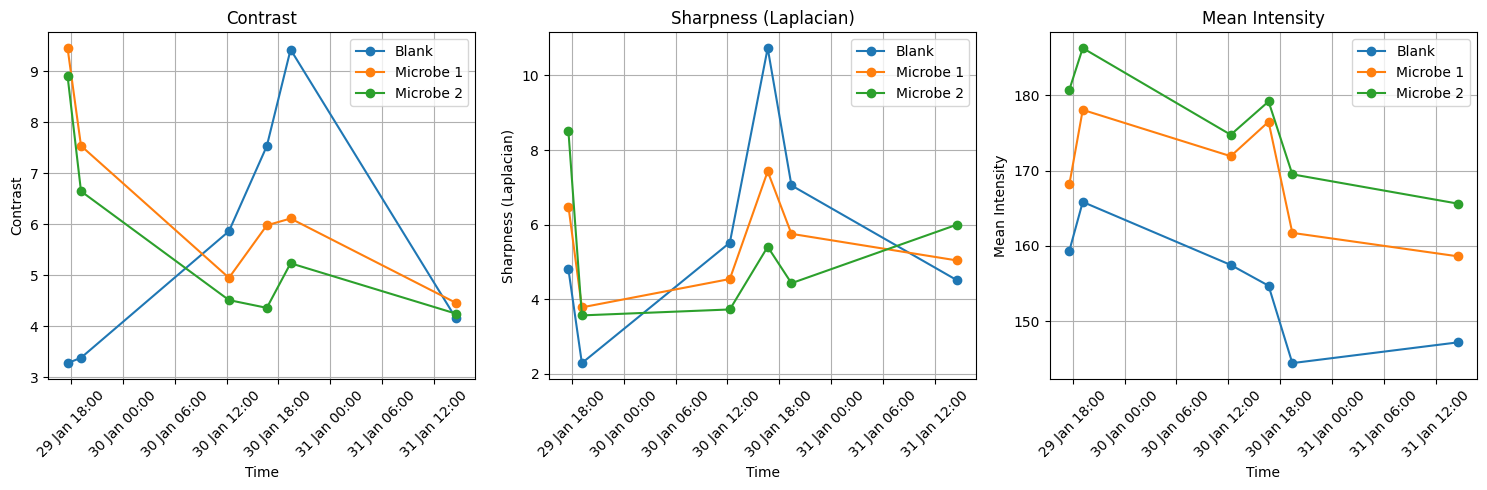

In [11]:
# Extract datetime from filenames
timestamps = []

for image_path in image_list_mars:
    filename = os.path.basename(image_path)
    name_without_ext = os.path.splitext(filename)[0]
    
    dt = datetime.strptime(name_without_ext, "%Y%m%d %H%M%S")
    timestamps.append(dt)

timestamps = np.array(timestamps)

metric_names = ["Contrast", "Sharpness (Laplacian)", "Mean Intensity"]

# Custom row labels
row_labels = ["Blank", "Microbe 1", "Microbe 2"]

plt.figure(figsize=(15, 5))

for metric_idx in range(3):
    ax = plt.subplot(1, 3, metric_idx + 1)

    for row in range(all_time_data_mars.shape[1]):
        ax.plot(
            timestamps,
            all_time_data_mars[:, row, metric_idx],
            marker='o',
            label=row_labels[row]   # <-- changed here
        )

    ax.set_title(metric_names[metric_idx])
    ax.set_xlabel("Time")
    ax.set_ylabel(metric_names[metric_idx])

    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M'))

    plt.xticks(rotation=45)
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()


In [12]:
row_labels = ["Blank", "Microbe 1", "Microbe 2"]

df_earth = build_dataframe(
    image_list_earth,
    all_time_data_earth,
    gravity_value=1.0,
    row_labels=row_labels
)

df_mars = build_dataframe(
    image_list_mars,
    all_time_data_mars,
    gravity_value=0.384,
    row_labels=row_labels
)

df_combined = pd.concat([df_earth, df_mars], ignore_index=True)

df_combined = df_combined.sort_values(["Gravity", "Time"])

print(df_combined.to_string(index=False))

               Time    Sample  Gravity  Contrast  Sharpness  Mean_Intensity
2026-01-29 17:37:13     Blank    0.384  3.273070   4.798237      159.345064
2026-01-29 17:37:13 Microbe 1    0.384  9.451562   6.485412      168.163741
2026-01-29 17:37:13 Microbe 2    0.384  8.901889   8.497817      180.740135
2026-01-29 19:10:23     Blank    0.384  3.377460   2.286758      165.846834
2026-01-29 19:10:23 Microbe 1    0.384  7.535294   3.781636      178.079119
2026-01-29 19:10:23 Microbe 2    0.384  6.644149   3.566195      186.284989
2026-01-30 12:16:46     Blank    0.384  5.860919   5.517014      157.478400
2026-01-30 12:16:46 Microbe 1    0.384  4.945467   4.541872      171.924033
2026-01-30 12:16:46 Microbe 2    0.384  4.508966   3.725575      174.771501
2026-01-30 16:39:17     Blank    0.384  7.529900  10.734563      154.718001
2026-01-30 16:39:17 Microbe 1    0.384  5.975167   7.428530      176.502312
2026-01-30 16:39:17 Microbe 2    0.384  4.356750   5.405955      179.193872
2026-01-30 1

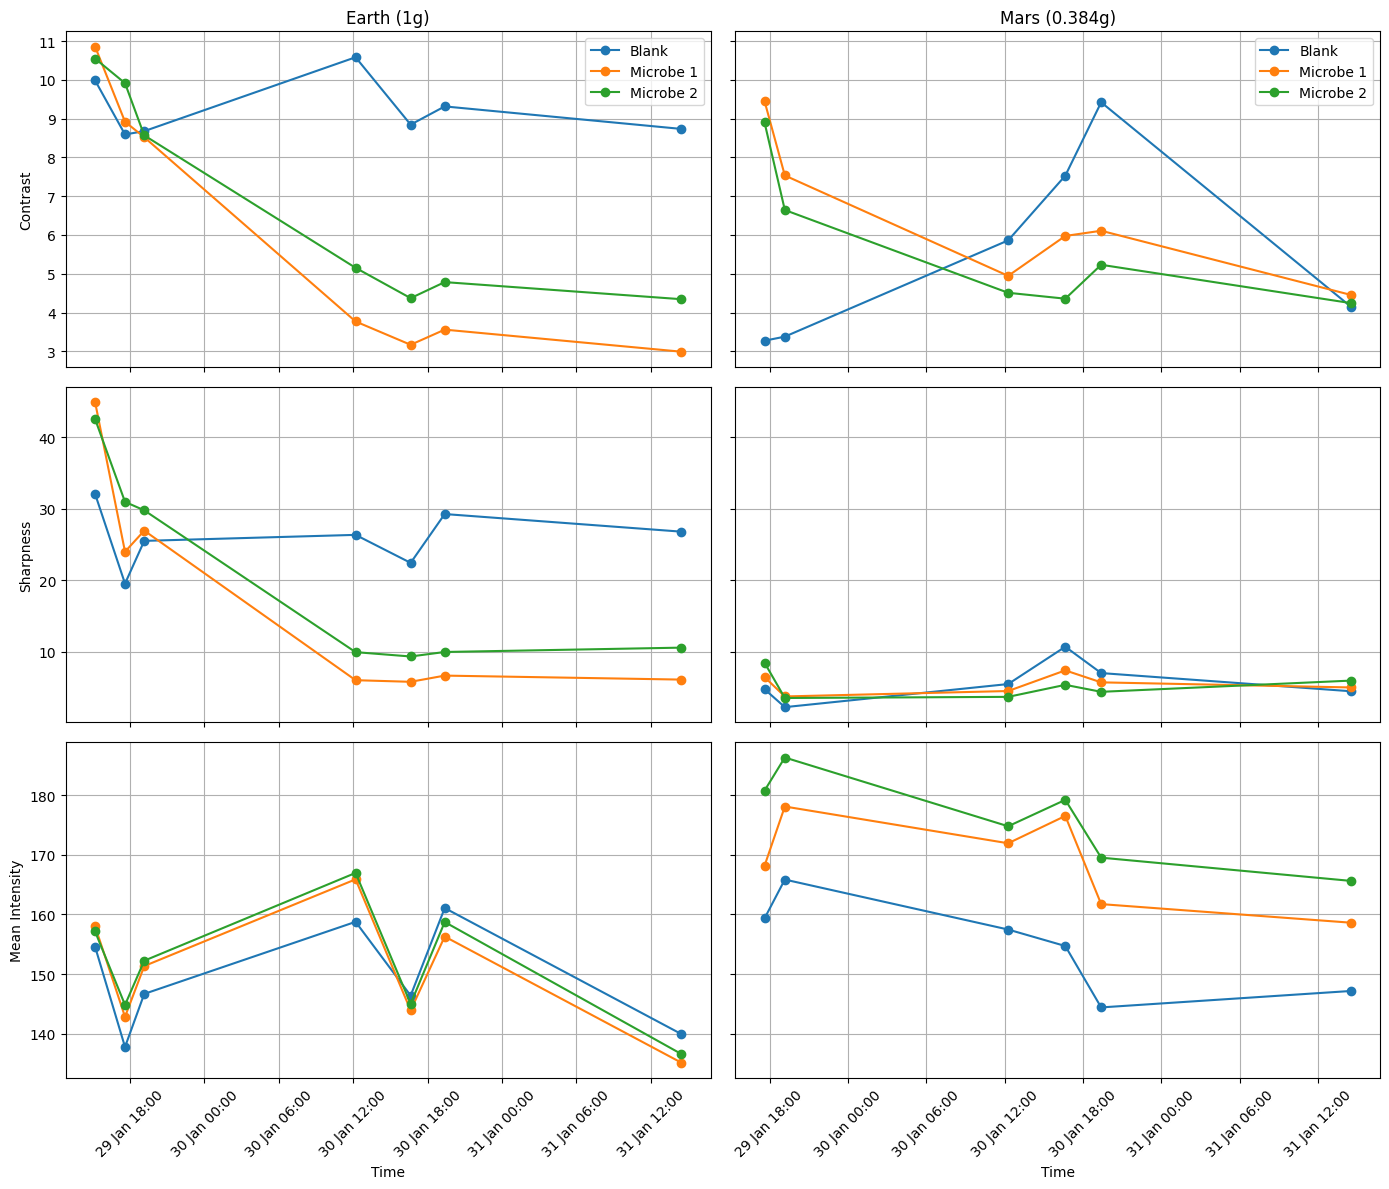

In [ ]:
# -------------------------------
# Create 3x2 grid
# -------------------------------

fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex='col', sharey='row')

for metric_idx in range(3):

    # -------- Earth column (col 0) --------
    ax_earth = axes[metric_idx, 0]

    for row in range(all_time_data_earth.shape[1]):
        ax_earth.plot(
            timestamps_earth,
            all_time_data_earth[:, row, metric_idx],
            marker='o',
            label=row_labels[row]
        )

    if metric_idx == 0:
        ax_earth.set_title("Earth (1g)")
        ax_earth.legend()

    ax_earth.set_ylabel(metric_names[metric_idx])
    ax_earth.grid(True)

    # -------- Mars column (col 1) --------
    ax_mars = axes[metric_idx, 1]

    for row in range(all_time_data_mars.shape[1]):
        ax_mars.plot(
            timestamps_mars,
            all_time_data_mars[:, row, metric_idx],
            marker='o',
            label=row_labels[row]
        )

    if metric_idx == 0:
        ax_mars.set_title("Mars (0.384g)")
        ax_mars.legend()

    ax_mars.grid(True)

# -------------------------------
# Format X-axis (only bottom row)
# -------------------------------

for col in range(2):
    axes[2, col].set_xlabel("Time")
    axes[2, col].xaxis.set_major_locator(mdates.AutoDateLocator())
    axes[2, col].xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M'))
    axes[2, col].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()